In [1]:
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Pour des résultats un peu plus reproductibles
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32


### Utilitaires

In [4]:
inf_clip = 1e5

def set_requires_grad(x, flag=True):
    x.requires_grad_(flag)
    return x

def relative_l2(pred, true, eps=1e-12):
    num = torch.sum((pred - true) ** 2)
    den = torch.sum(true ** 2) + eps
    return torch.sqrt(num / den)

def gradients(y, x):
    return torch.autograd.grad(
        y, x, # on calcule dy/dx
        grad_outputs=torch.ones_like(y),
        create_graph=True, # permet de dériver plusieurs fois si nécessaire
        retain_graph=True,
        only_inputs=True
    )[0]

def safe_log(r, eps=1e-12):
    return torch.log(torch.clamp(r, min=eps))

def clip_singular(u, clip_value=inf_clip):
    u = torch.nan_to_num(u, nan=clip_value, posinf=clip_value, neginf=-clip_value)
    u = torch.clamp(u, min=-clip_value, max=clip_value)
    return u

### Utilitaires pour l'échantillonnage de points intérieurs

In [7]:

def cart2pol(xy):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    r = torch.sqrt(x**2 + y**2)
    a = torch.atan2(y, x)
    return r, a

def sample_interior_points_laplace(n_pts, t_value, box=(-2.0, 2.0, -2.0, 2.0), max_tries=20):
    xmin, xmax, ymin, ymax = box
    pts_list = []

    for _ in range(max_tries):
        cand = torch.empty(n_pts, 2, device=device, dtype=dtype)
        cand[:, 0] = xmin + (xmax - xmin) * torch.rand(n_pts, device=device, dtype=dtype)
        cand[:, 1] = ymin + (ymax - ymin) * torch.rand(n_pts, device=device, dtype=dtype)

        r, a = cart2pol(cand)
        rt = 1.0 + 0.2 * (
            torch.sin(3.0 * a)
            + t_value * torch.sin(4.0 * a)
            + torch.sin(6.0 * a)
            + torch.cos(2.0 * a)
            + torch.cos(5.0 * a)
        )
        keep = (r < rt).squeeze(-1)
        pts_list.append(cand[keep])

        total = sum(x.shape[0] for x in pts_list)
        if total >= n_pts:
            return torch.cat(pts_list, dim=0)[:n_pts]

    return torch.cat(pts_list, dim=0)[:n_pts]

def sample_interior_points_biharmonic(n_pts, t_value, box=(-2.0, 2.0, -2.0, 2.0), max_tries=20):
    xmin, xmax, ymin, ymax = box
    pts_list = []

    for _ in range(max_tries):
        cand = torch.empty(n_pts, 2, device=device, dtype=dtype)
        cand[:, 0] = xmin + (xmax - xmin) * torch.rand(n_pts, device=device, dtype=dtype)
        cand[:, 1] = ymin + (ymax - ymin) * torch.rand(n_pts, device=device, dtype=dtype)

        r, a = cart2pol(cand)
        rt = 1.0 + 0.1 * (
            torch.sin(a)
            + t_value * torch.cos(2.0 * a)
            + torch.sin(3.0 * a)
            + torch.cos(4.0 * a)
        )
        keep = (r < rt).squeeze(-1)
        pts_list.append(cand[keep])

        total = sum(x.shape[0] for x in pts_list)
        if total >= n_pts:
            return torch.cat(pts_list, dim=0)[:n_pts]

    return torch.cat(pts_list, dim=0)[:n_pts]



### Utilitaires pour la visualisation

In [17]:
def plot_prediction(xy, u_true, u_pred, title_prefix=""):
    xy_np = xy.detach().cpu().numpy()
    ut = u_true.detach().cpu().numpy().squeeze()
    up = u_pred.detach().cpu().numpy().squeeze()
    diff = ut - up

    cmin = min(ut.min(), up.min())
    cmax = max(ut.max(), up.max())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=130)

    sc = axes[0].scatter(xy_np[:, 0], xy_np[:, 1], c=up, s=1, cmap="jet", vmin=cmin, vmax=cmax)
    axes[0].set_title(f"{title_prefix}Prediction")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(sc, ax=axes[0])

    sc = axes[1].scatter(xy_np[:, 0], xy_np[:, 1], c=ut, s=1, cmap="jet", vmin=cmin, vmax=cmax)
    axes[1].set_title(f"{title_prefix}Ground truth")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    plt.colorbar(sc, ax=axes[1])

    sc = axes[2].scatter(xy_np[:, 0], xy_np[:, 1], c=diff, s=1, cmap="jet", vmin = cmin, vmax = cmax)
    axes[2].set_title(f"{title_prefix}Difference")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    plt.colorbar(sc, ax=axes[2])

    plt.tight_layout()
    plt.show()

## Géométries de deux exemples

### Exemple 1 : Laplace 2D
La frontière est paramétrée par $t\in[1,2]$: 
$$
r(\alpha;t) = 1 + 0.2\left[\sin(3\alpha) + t\sin(4\alpha) + \sin(6\alpha) + \cos(2\alpha) + \cos(5\alpha)\right],
\quad \alpha \in [0, 2\pi).
$$

La condition au bord est imposée par la solution analytique :
$$
u_0(x,y) = e^x \sin(y).
$$

### Exemple 2 : Bi-harmonique 2D
La frontière est paramétrée par : 
$$
r(\alpha;t) = 1 + 0.1\left[\sin(\alpha) + t\cos(2\alpha) + \sin(3\alpha) + \cos(4\alpha)\right].
$$

et on a 
$$
u_0(x,y) = (x^2+y^2)e^x\sin(y).
$$

(Le code GitHub ajoute aussi une petite correction polynomiale `p0(y)` dans le cas bi-harmonique,
ce que l'on reprend ici. ?)

In [2]:
def sample_alpha(n_alpha, device=device):
    return torch.linspace(0.0, 2.0 * math.pi, n_alpha + 1, device=device, dtype=dtype)[:-1] # on ne prend pas 2 pi

# Exemple 1 : Laplace 2D

def laplace_radius(alpha, t):
    # alpha : [M]
    # t     : [B, 1]
    alpha = alpha[None, :]  # [1, M]
    return 1.0 + 0.2 * (
        torch.sin(3.0 * alpha)
        + t * torch.sin(4.0 * alpha)
        + torch.sin(6.0 * alpha)
        + torch.cos(2.0 * alpha)
        + torch.cos(5.0 * alpha)
    )

def laplace_boundary(alpha, t):
    """
    Retourne :
    pts : [B, M, 2]
    jac : [B, M, 1] = ds/dalpha
    normal_unitaire : [B, M, 2]
    """
    alpha_b = alpha[None, :]  # [1, M]
    r = laplace_radius(alpha, t)  # [B, M]

    x = r * torch.cos(alpha_b)
    y = r * torch.sin(alpha_b)

    # dérivée radiale dr/dalpha
    dr = 0.2 * (
        3.0 * torch.cos(3.0 * alpha_b)
        + 4.0 * t * torch.cos(4.0 * alpha_b)
        + 6.0 * torch.cos(6.0 * alpha_b)
        - 2.0 * torch.sin(2.0 * alpha_b)
        - 5.0 * torch.sin(5.0 * alpha_b)
    )

    # dérivée cartésienne de la courbe paramétrée
    dx = dr * torch.cos(alpha_b) - r * torch.sin(alpha_b)
    dy = dr * torch.sin(alpha_b) + r * torch.cos(alpha_b)

    jac = torch.sqrt(dx**2 + dy**2).unsqueeze(-1)  # [B, M, 1]

    # normale unitaire obtenue par rotation du vecteur tangent
    normal = torch.stack([dy, -dx], dim=-1)
    normal = normal / (torch.norm(normal, dim=-1, keepdim=True) + 1e-12)

    pts = torch.stack([x, y], dim=-1)
    return pts, jac, normal

def laplace_exact_u(xy):
    x = xy[..., 0:1]
    y = xy[..., 1:2]
    return torch.exp(x) * torch.sin(y)


# Exemple 2 : Bi-harmonique 2D

def biharmonic_radius(alpha, t):
    alpha = alpha[None, :]
    return 1.0 + 0.1 * (
        torch.sin(alpha)
        + t * torch.cos(2.0 * alpha)
        + torch.sin(3.0 * alpha)
        + torch.cos(4.0 * alpha)
    )

def biharmonic_boundary(alpha, t):
    """
    Retourne :
    pts : [B, M, 2]
    jac : [B, M, 1]
    normal_unitaire : [B, M, 2]
    """
    alpha_b = alpha[None, :]
    r = biharmonic_radius(alpha, t)

    x = r * torch.cos(alpha_b)
    y = r * torch.sin(alpha_b)

    # dr/dalpha
    dr = 0.1 * (
        torch.cos(alpha_b)
        - 2.0 * t * torch.sin(2.0 * alpha_b)
        + 3.0 * torch.cos(3.0 * alpha_b)
        - 4.0 * torch.sin(4.0 * alpha_b)
    )

    dx = dr * torch.cos(alpha_b) - r * torch.sin(alpha_b)
    dy = dr * torch.sin(alpha_b) + r * torch.cos(alpha_b)

    jac = torch.sqrt(dx**2 + dy**2).unsqueeze(-1)

    normal = torch.stack([dy, -dx], dim=-1)
    normal = normal / (torch.norm(normal, dim=-1, keepdim=True) + 1e-12)

    pts = torch.stack([x, y], dim=-1)
    return pts, jac, normal

def biharmonic_exact_u(xy):
    x = xy[..., 0:1]
    y = xy[..., 1:2]
    return (x**2 + y**2) * torch.exp(x) * torch.sin(y)

def biharmonic_exact_dudn(xy, normal):
    """
    Dérivée normale de u sur la frontière
    """
    x = xy[..., 0:1]
    y = xy[..., 1:2]
    nx = normal[..., 0:1]
    ny = normal[..., 1:2]

    return torch.exp(x) * (
        ny * (x**2 + y**2) * torch.cos(y)
        + (2.0 * ny * y + nx * (2.0 * x + x**2 + y**2)) * torch.sin(y)
    )

In [5]:
# Noyaux intégral frontière

def pairwise_diff(src, trg):
    """
    src : [B, M, 2]
    trg : [B, N, 2]
    retourne d = src[:, None, :, :] - trg[:, :, None, :] -> [B, N, M, 2]
    """
    return src[:, None, :, :] - trg[:, :, None, :]

def laplace_2d_star(src, trg, clip_value=inf_clip):
    d = pairwise_diff(src, trg)                      # [B, N, M, 2]
    r = torch.norm(d, dim=-1)                       # [B, N, M]
    u = -safe_log(r) / (2.0 * math.pi)
    return clip_singular(u, clip_value=clip_value)

def biharmonic_2d_star(src, trg, clip_value=inf_clip):
    d = pairwise_diff(src, trg)
    r = torch.norm(d, dim=-1)
    u = torch.special.xlogy(r**2, r) / (8.0 * math.pi)  # r^2 log(r) / 8pi
    return clip_singular(u, clip_value=clip_value)

def biharmonic_2d_nx(src, trg, normal_src, clip_value=inf_clip):
    """
    dérivée normale côté source
    src        : [B, M, 2]
    trg        : [B, N, 2]
    normal_src : [B, M, 2]
    """
    d = pairwise_diff(src, trg)                     # [B, N, M, 2]
    r = torch.norm(d, dim=-1)                       # [B, N, M]
    inner = torch.einsum("bmd,bnmd->bnm", normal_src, d)
    u = (2.0 * safe_log(r) + 1.0) * inner / (8.0 * math.pi)
    return clip_singular(u, clip_value=clip_value)

def biharmonic_2d_ny(src, trg, normal_trg, clip_value=inf_clip):
    """
    dérivée normale côté cible
    """
    d = pairwise_diff(src, trg)                     # [B, N, M, 2]
    r = torch.norm(d, dim=-1)
    inner = -torch.einsum("bnd,bnmd->bnm", normal_trg, d)
    u = (2.0 * safe_log(r) + 1.0) * inner / (8.0 * math.pi)
    return clip_singular(u, clip_value=clip_value)

def biharmonic_2d_nxny(src, trg, normal_src, normal_trg, clip_value=inf_clip):
    d = pairwise_diff(src, trg)                     # [B, N, M, 2]
    r = torch.norm(d, dim=-1)                       # [B, N, M]

    rx = torch.einsum("bmd,bnmd->bnm", normal_src, d)
    ry = torch.einsum("bnd,bnmd->bnm", normal_trg, d)
    nxny = torch.einsum("bmd,bnd->bnm", normal_src, normal_trg)

    u = -(2.0 * safe_log(r) + 1.0) * nxny / (8.0 * math.pi) - (rx * ry) / (4.0 * math.pi * (r**2 + 1e-12))
    return clip_singular(u, clip_value=clip_value)

## Architecture NOMAD

Le papier utilise NOMAD avec :
- un **encodeur** pour l'information de paramètre / observation,
- un **décodeur** (trunk) qui dépend de la position,
- des **Fourier features** pour mieux capturer les hautes fréquences.

Avec 3 couches cachées de taille 100 dans les MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, layers, activation=nn.GELU()):
        super().__init__()
        mods = []
        for i in range(len(layers) - 2):
            mods.append(nn.Linear(layers[i], layers[i+1]))
            mods.append(activation)
        mods.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*mods)
        self.reset_parameters()

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

class GaussianFourierFeatures(nn.Module):
    """
    Mapping de Fourier
    x -> [sin(Bx), cos(Bx)]
    """
    def __init__(self, in_dim=2, num_features=50, sigma=2.0):
        super().__init__()
        B = sigma * torch.randn(in_dim, num_features)
        self.register_buffer("B", B)

    def forward(self, x):
        """
        x : [..., in_dim]
        sortie : [..., 2*num_features]
        """
        proj = 2.0 * math.pi * x @ self.B
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

class NOMADDensity(nn.Module):
    """
    NOMAD pour apprendre une densité de frontière.

    - branch(t) : [B, p]
    - trunk(phi(x)) : [B, M, p]
    - output : [B, M, out_dim]
    """
    def __init__(self, t_dim=1, x_dim=2, p=100, out_dim=1, fourier_features=50, sigma=2.0):
        super().__init__()
        self.p = p
        self.out_dim = out_dim

        self.branch = MLP([t_dim, 100, 100, 100, p], activation=nn.GELU())
        self.fourier = GaussianFourierFeatures(in_dim=x_dim, num_features=fourier_features, sigma=sigma)
        self.trunk = MLP([2 * fourier_features, 100, 100, 100, p], activation=nn.GELU())
        self.head = nn.Linear(p, out_dim)

        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, t, x):
        """
        t : [B, 1]
        x : [B, M, 2]
        """
        b = self.branch(t)                         # [B, p]
        phi = self.fourier(x)                      # [B, M, 2m]
        tau = self.trunk(phi)                      # [B, M, p]

        z = tau * b[:, None, :]                    # [B, M, p]
        out = self.head(z)                         # [B, M, out_dim]
        return out

## Exemple complet : Laplace 2D

On considère l’équation de Laplace dans un domaine paramétré par \(t\)

$$
\Delta u(x)=0 \quad \text{dans } \Omega_t, 
\qquad 
u(x)=u_0(x) \quad \text{sur } \Gamma_t
$$

avec la condition de bord

$$
u_0(x,y)=e^x \sin(y).
$$

La fonction de Green de ce problème est

$$
u^*(x,y)=-\frac{1}{2\pi}\log|x-y|.
$$

La solution peut être représentée par une équation intégrale sur la frontière

$$
u(y;t)=\int_{\Gamma_t} v(x;t)\,u^*(x,y)\,d\tau.
$$

et l'inconnue devient

$$
v(x;t)=
\left[\frac{\partial u(x;t)}{\partial n}\right]
\left|\frac{ds}{d\tau}\right|,
$$


Le réseau apprend $v(x;t)$ en imposant la condition de bord

$$
u_0(y_t)=\int_{\Gamma_t} v(x;t)u^*(x,y_t)d\tau
\quad y_t\in\Gamma_t.
$$

(L’intégrale est approximée par Monte-Carlo)


Une fois $v$ appris, la solution $u(y;t)$ peut être reconstruite en tout point du domaine.

In [ ]:
class LaplaceBoundaryOperator(nn.Module):
    def __init__(self, p=100, fourier_features=50, sigma=2.0):
        super().__init__()
        self.density_net = NOMADDensity(
            t_dim=1,
            x_dim=2,
            p=p,
            out_dim=1,
            fourier_features=fourier_features,
            sigma=sigma
        )

    def predict_density(self, t, boundary_pts, jac):
        """
        v(alpha; t) = density * jacobian ds/dalpha
        """
        raw = self.density_net(t, boundary_pts)   # [B, M, 1]       # le réseau apprend le saut de du/dn
        return raw * jac                          # [B, M, 1]       # on multiplie par ds/dalpha pour obtenir la densité dans l'intégrale de frontière

    def boundary_reconstruction(self, t, src_pts, src_jac, query_pts):
        """
        Reconstruit u(query_pts) à partir de l'intégrale de frontière discrète.
        """
        v = self.predict_density(t, src_pts, src_jac)        # [B, M, 1]
        G = laplace_2d_star(src_pts, query_pts)             # [B, N, M]     # noyau de Green pour Laplace 2D
        M = src_pts.shape[1]
        u = (2.0 * math.pi / M) * torch.matmul(G, v)         # [B, N, 1]    # approximation de l'intégrale par Monte-Carlo
        return u

def train_laplace_model(
    model,
    steps=20000,
    lr=1e-3,
    lr_step=20000,
    lr_gamma=0.95,
    num_geo=10, # nombre de géométries différentes par batch (différents t)
    nr_int=3000, # nombre de points d'intégration sur la frontière (approximation de l'intégrale)
    nr_query=100, # nombre de points sur la frontière pour calculer la perte à chaque étape
    print_every=500
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_step, gamma=lr_gamma)
    mse = nn.MSELoss()

    alpha_int = sample_alpha(nr_int, device=device) # points d'intégration sur la frontière pour approximer l'intégrale de frontière
    alpha_q = sample_alpha(nr_query, device=device) # points sur la frontière pour calculer la perte à chaque étape

    loss_history = []
    t0 = time.time()

    model.train()
    for step in range(1, steps + 1):
        t_batch = 1.0 + torch.rand(num_geo, 1, device=device, dtype=dtype)  # t dans [1, 2]

        pts_int, jac_int, _ = laplace_boundary(alpha_int, t_batch)
        pts_q, _, _ = laplace_boundary(alpha_q, t_batch)

        u_pred = model.boundary_reconstruction(t_batch, pts_int, jac_int, pts_q)
        u_true = laplace_exact_u(pts_q)

        loss = mse(u_pred, u_true)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        loss_history.append(loss.item())

        if step % print_every == 0 or step == 1:
            elapsed = time.time() - t0
            print(f"[Laplace] step {step:6d}/{steps} | loss = {loss.item():.6e} | {elapsed:.1f}s")
            t0 = time.time()

    return loss_history

@torch.no_grad()
def evaluate_laplace_model(model, t_value, n_eval=80000, nr_int=3000):
    model.eval()

    alpha_int = sample_alpha(nr_int, device=device)
    t_tensor = torch.tensor([[t_value]], device=device, dtype=dtype)

    pts_int, jac_int, _ = laplace_boundary(alpha_int, t_tensor)
    xy = sample_interior_points_laplace(n_eval, t_value).to(device)
    query = xy.unsqueeze(0)

    u_pred = model.boundary_reconstruction(t_tensor, pts_int, jac_int, query).squeeze(0)
    u_true = laplace_exact_u(query).squeeze(0)
    err = relative_l2(u_pred, u_true).item()

    return xy, u_true, u_pred, err

[Laplace] step      1/2000 | loss = 8.896220e-01 | 0.2s
[Laplace] step    100/2000 | loss = 5.193863e-03 | 17.3s
[Laplace] step    200/2000 | loss = 1.334487e-03 | 19.6s
[Laplace] step    300/2000 | loss = 6.750555e-04 | 19.8s
[Laplace] step    400/2000 | loss = 5.039402e-04 | 23.4s
[Laplace] step    500/2000 | loss = 2.458601e-04 | 25.6s
[Laplace] step    600/2000 | loss = 3.790630e-04 | 31.8s
[Laplace] step    700/2000 | loss = 2.171834e-04 | 29.6s
[Laplace] step    800/2000 | loss = 1.315199e-04 | 29.5s
[Laplace] step    900/2000 | loss = 9.076527e-05 | 29.1s
[Laplace] step   1000/2000 | loss = 8.077864e-05 | 21.6s
[Laplace] step   1100/2000 | loss = 1.235573e-04 | 21.8s
[Laplace] step   1200/2000 | loss = 6.198941e-05 | 18.8s
[Laplace] step   1300/2000 | loss = 5.575954e-05 | 19.5s
[Laplace] step   1400/2000 | loss = 4.492043e-05 | 28.8s
[Laplace] step   1500/2000 | loss = 5.699707e-05 | 26.3s
[Laplace] step   1600/2000 | loss = 3.108253e-05 | 22.2s
[Laplace] step   1700/2000 | los

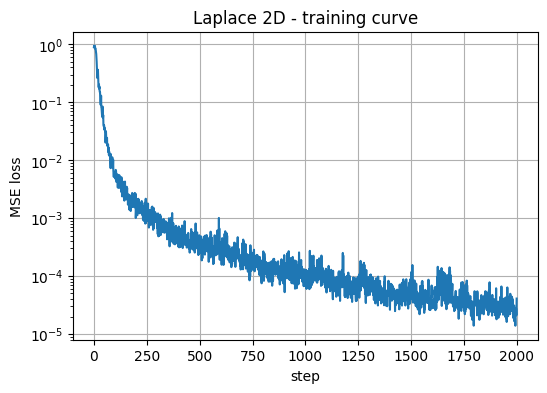

In [ ]:
laplace_model = LaplaceBoundaryOperator(
    p=100,
    fourier_features=50,   # d'après l'annexe de l'article
    sigma=2.0
).to(device)

laplace_loss = train_laplace_model(
    laplace_model,
    steps=2000,   
    lr=1e-3,
    lr_step=2000,
    lr_gamma=0.95,
    num_geo=10,
    nr_int=3000,
    nr_query=100,
    print_every=100
)

plt.figure(figsize=(6, 4))
plt.plot(laplace_loss)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("Laplace 2D - training curve")
plt.grid(True)
plt.show()

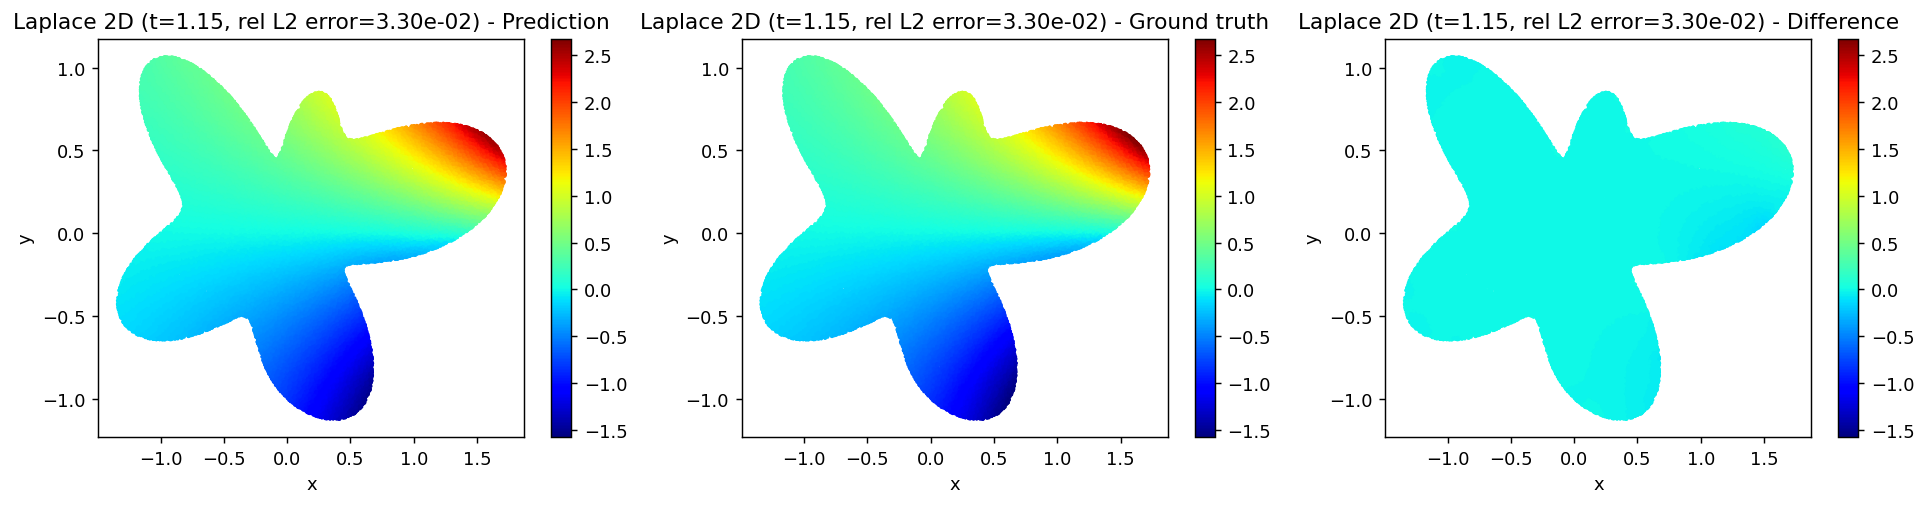

In [19]:
xy, u_true, u_pred, err = evaluate_laplace_model(laplace_model, t_value=1.15)
plot_prediction(xy, u_true, u_pred, title_prefix=f"Laplace 2D (t={1.15:.2f}, rel L2 error={err:.2e}) - ")

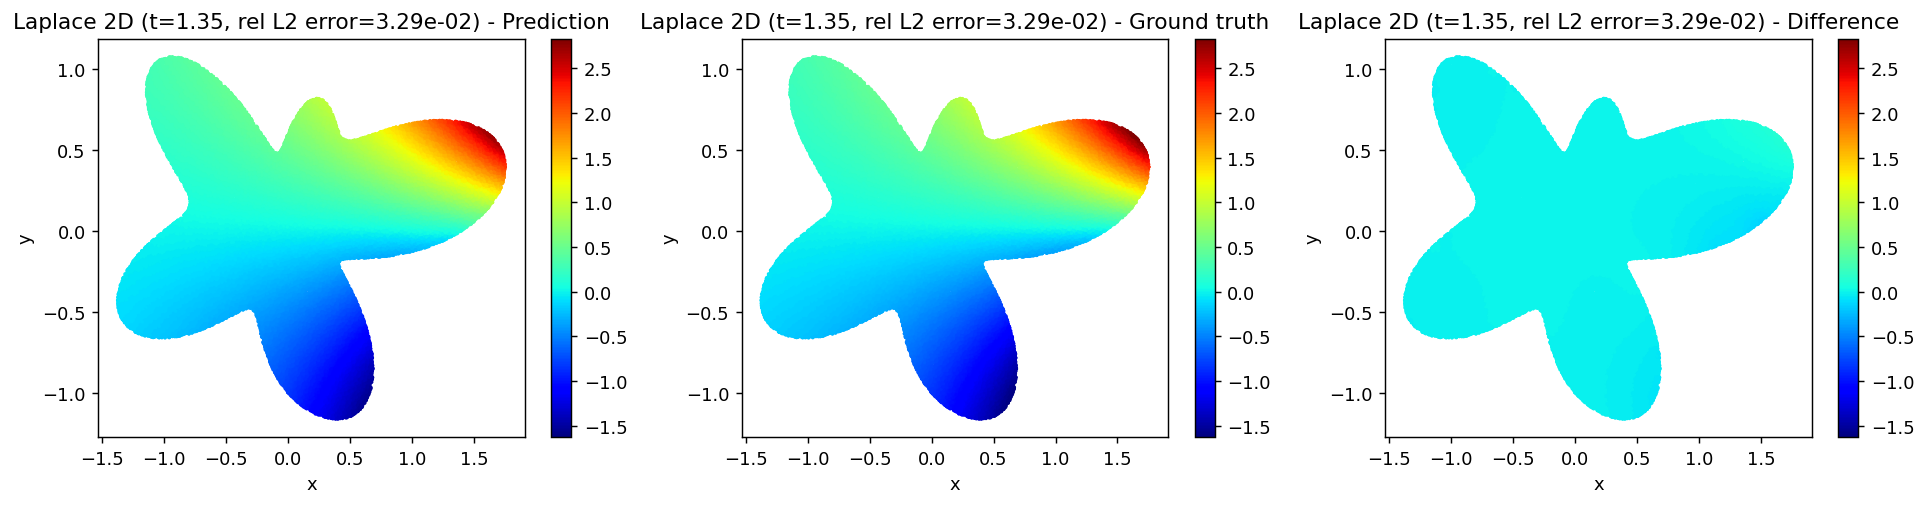

In [20]:
xy, u_true, u_pred, err = evaluate_laplace_model(laplace_model, t_value=1.35)
plot_prediction(xy, u_true, u_pred, title_prefix=f"Laplace 2D (t={1.35:.2f}, rel L2 error={err:.2e}) - ")

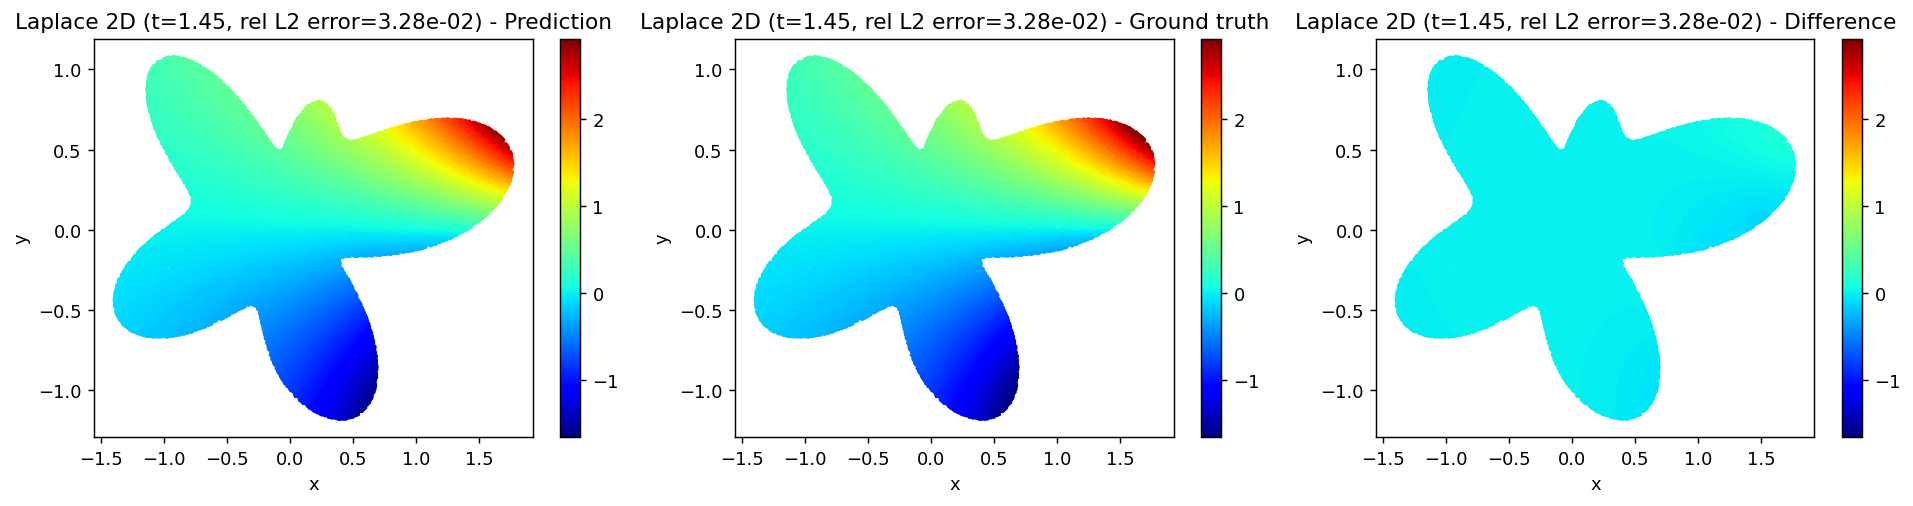

In [21]:
xy, u_true, u_pred, err = evaluate_laplace_model(laplace_model, t_value=1.45)
plot_prediction(xy, u_true, u_pred, title_prefix=f"Laplace 2D (t={1.45:.2f}, rel L2 error={err:.2e}) - ")

## Exemple complet : Biharmonic 2D

On considère l’équation biharmonique

$$
\Delta^2 u(x)=0 \quad \text{dans } \mathbb{R}^2 \setminus \Gamma_t
$$

avec conditions de bord

$$
u(x)=u_0(x),
\qquad
\frac{\partial u(x)}{\partial n}
=
\frac{\partial u_0(x)}{\partial n}
\quad \text{sur } \Gamma_t.
$$

Dans l’article, la solution utilisée pour définir les conditions de bord est

$$
u_0(x,y)=(x^2+y^2)e^x\sin(y).
$$

La fonction de Green du biharmonique est

$$
u^*(x,y)=\frac{1}{8\pi}|x-y|^2\log|x-y|.
$$

La solution admet la représentation intégrale

$$
u(y)=
-\int_{\Gamma_t}
\frac{\partial v(x;t)}{\partial n}u^*(x,y)
+
v(x;t)\frac{\partial u^*(x,y)}{\partial n_x}
\,ds.
$$

où la fonction inconnue $v(x;t)$ est définie sur la frontière et est apprise par le réseau.

Les intégrales sont aussi approximées par Monte-Carlo.

Cette fois on a besoin de $v(x;t)$ et de sa dérivée normale. Par ailleurs, la loss choisie moyenne l'erreur sur $u$ et sur $ \partial u / \partial n$


In [ ]:
class BiharmonicBoundaryOperator(nn.Module):
    def __init__(self, p=100, fourier_features=50, sigma=2.0):
        super().__init__()
        self.density_net = NOMADDensity(
            t_dim=1,
            x_dim=2,
            p=p,
            out_dim=1,
            fourier_features=fourier_features,
            sigma=sigma
        )

        # on ajoute une correction polynomiale, comme dans le GitHub de l'article
        self.poly_net = MLP([2, 64, 64, 1], activation=nn.GELU())

    def forward_density(self, t, boundary_pts):
        return self.density_net(t, boundary_pts)  # [B, M, 1]

    def reconstruct_u_and_dudn(self, t, src_pts, src_normal, query_pts, query_normal):
        """
        Reprend la structure du script GitHub :
        u  = 2pi/M * (-G * dvdn + G_nx * v) + p0
        du = 2pi/M * (-G_ny * dvdn + G_nxny * v) + dp0/dn
        """
        src_pts = set_requires_grad(src_pts, True)
        query_pts = set_requires_grad(query_pts, True)

        v = self.forward_density(t, src_pts)           # [B, M, 1]
        dv = gradients(v, src_pts)                     # [B, M, 2]       # en coordonnées cartésiennes
        dvdn = torch.sum(dv * src_normal, dim=-1, keepdim=True)  # [B, M, 1]    # dérivée normale côté source

        p0 = self.poly_net(query_pts)                  # [B, N, 1]      # la correction
        dp0 = gradients(p0, query_pts)                 # [B, N, 2]
        dp0dn = torch.sum(dp0 * query_normal, dim=-1, keepdim=True)

        G = biharmonic_2d_star(src_pts, query_pts)
        G_nx = biharmonic_2d_nx(src_pts, query_pts, src_normal)
        G_ny = biharmonic_2d_ny(src_pts, query_pts, query_normal)
        G_nxny = biharmonic_2d_nxny(src_pts, query_pts, src_normal, query_normal)

        M = src_pts.shape[1]
        # Reconstruction de u et de du/dn à partir de l'intégrale de frontière discrète (monte-carlo) + correction polynomiale
        u = (2.0 * math.pi / M) * (-torch.matmul(G, dvdn) + torch.matmul(G_nx, v)) + p0
        dudn = (2.0 * math.pi / M) * (-torch.matmul(G_ny, dvdn) + torch.matmul(G_nxny, v)) + dp0dn

        return u, dudn

    def reconstruct_u_inside(self, t, src_pts, src_normal, query_pts):
        """
        Reconstruction dans le domaine intérieur pour l'évaluation.
        """
        src_pts = set_requires_grad(src_pts, True)
        query_pts = set_requires_grad(query_pts, True)

        v = self.forward_density(t, src_pts)
        dv = gradients(v, src_pts)
        dvdn = torch.sum(dv * src_normal, dim=-1, keepdim=True)

        p0 = self.poly_net(query_pts)

        G = biharmonic_2d_star(src_pts, query_pts)
        G_nx = biharmonic_2d_nx(src_pts, query_pts, src_normal)

        M = src_pts.shape[1]
        u = (2.0 * math.pi / M) * (-torch.matmul(G, dvdn) + torch.matmul(G_nx, v)) + p0
        return u

def train_biharmonic_model(
    model,
    steps=20000,
    lr=1e-3,
    lr_step=20000,
    lr_gamma=0.95,
    num_geo=10,
    nr_int=3000,
    nr_query=100,
    print_every=500
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_step, gamma=lr_gamma)
    mse = nn.MSELoss()

    alpha_int = sample_alpha(nr_int, device=device)
    alpha_q = sample_alpha(nr_query, device=device)

    loss_history = []
    t0 = time.time()

    model.train()
    for step in range(1, steps + 1):
        t_batch = 1.0 + torch.rand(num_geo, 1, device=device, dtype=dtype)  # t in [1, 2]

        src_pts, _, src_normal = biharmonic_boundary(alpha_int, t_batch)
        query_pts, _, query_normal = biharmonic_boundary(alpha_q, t_batch)

        u_pred, dudn_pred = model.reconstruct_u_and_dudn(
            t_batch, src_pts, src_normal, query_pts, query_normal
        )

        u_true = biharmonic_exact_u(query_pts)
        dudn_true = biharmonic_exact_dudn(query_pts, query_normal)

        loss_u = mse(u_pred, u_true)
        loss_n = mse(dudn_pred, dudn_true)
        loss = loss_u + loss_n # la loss prend en compte à la fois l'erreur sur u et sur sa dérivée normale (cf GitHub de l'article)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        loss_history.append(loss.item())

        if step % print_every == 0 or step == 1:
            elapsed = time.time() - t0
            print(
                f"[Biharmonic] step {step:6d}/{steps} | "
                f"loss = {loss.item():.6e} | "
                f"loss_u = {loss_u.item():.6e} | "
                f"loss_n = {loss_n.item():.6e} | {elapsed:.1f}s"
            )
            t0 = time.time()

    return loss_history

def evaluate_biharmonic_model(model, t_value, n_eval=80000, nr_int=3000):
    model.eval()

    alpha_int = sample_alpha(nr_int, device=device)
    t_tensor = torch.tensor([[t_value]], device=device, dtype=dtype)

    src_pts, _, src_normal = biharmonic_boundary(alpha_int, t_tensor)
    xy = sample_interior_points_biharmonic(n_eval, t_value).to(device)
    query = xy.unsqueeze(0)

    u_pred = model.reconstruct_u_inside(t_tensor, src_pts, src_normal, query).squeeze(0)
    u_true = biharmonic_exact_u(query).squeeze(0)
    err = relative_l2(u_pred, u_true).item()

    return xy, u_true, u_pred, err

[Biharmonic] step      1/1000 | loss = 8.964931e+00 | loss_u = 6.655608e-01 | loss_n = 8.299370e+00 | 0.5s
[Biharmonic] step     10/1000 | loss = 5.332922e+00 | loss_u = 2.451136e-01 | loss_n = 5.087809e+00 | 2.9s
[Biharmonic] step     20/1000 | loss = 3.904465e+00 | loss_u = 3.905893e-01 | loss_n = 3.513875e+00 | 3.5s
[Biharmonic] step     30/1000 | loss = 3.150130e+00 | loss_u = 5.110451e-01 | loss_n = 2.639085e+00 | 3.7s
[Biharmonic] step     40/1000 | loss = 2.346379e+00 | loss_u = 3.899455e-01 | loss_n = 1.956434e+00 | 3.7s
[Biharmonic] step     50/1000 | loss = 1.893426e+00 | loss_u = 3.998120e-01 | loss_n = 1.493614e+00 | 3.7s
[Biharmonic] step     60/1000 | loss = 1.549208e+00 | loss_u = 5.084917e-01 | loss_n = 1.040717e+00 | 3.7s
[Biharmonic] step     70/1000 | loss = 1.439707e+00 | loss_u = 4.291043e-01 | loss_n = 1.010603e+00 | 3.7s
[Biharmonic] step     80/1000 | loss = 1.433949e+00 | loss_u = 3.770944e-01 | loss_n = 1.056854e+00 | 3.7s
[Biharmonic] step     90/1000 | loss 

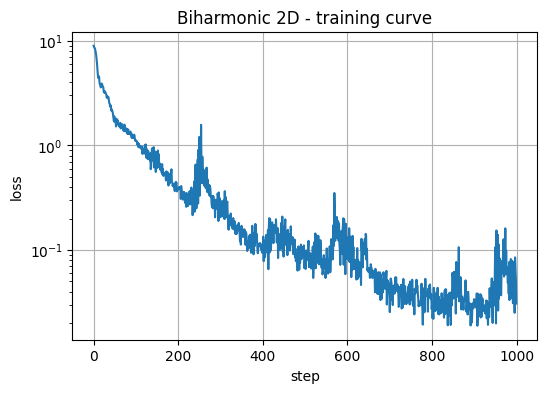

In [31]:
biharmonic_model = BiharmonicBoundaryOperator(
    p=100,
    fourier_features=50,
    sigma=2.0
).to(device)

biharmonic_loss = train_biharmonic_model(
    biharmonic_model,
    steps=1000,     
    lr=1e-3,
    lr_step=1000,
    lr_gamma=0.95,
    num_geo=10,
    nr_int=1000,
    nr_query=100,
    print_every=10
)

plt.figure(figsize=(6, 4))
plt.plot(biharmonic_loss)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Biharmonic 2D - training curve")
plt.grid(True)
plt.show()

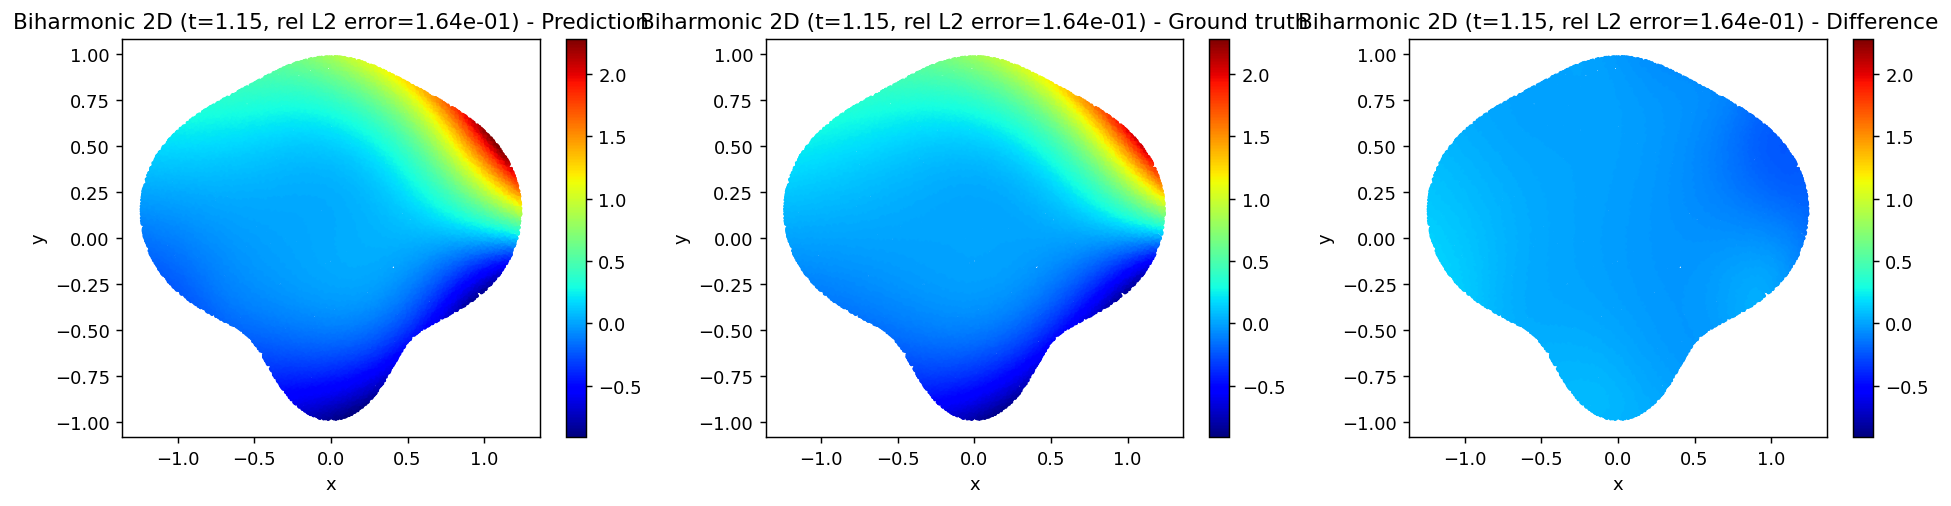

In [35]:
xy, u_true, u_pred, err = evaluate_biharmonic_model(biharmonic_model, t_value=1.15)
plot_prediction(xy, u_true, u_pred, title_prefix=f"Biharmonic 2D (t={1.15:.2f}, rel L2 error={err:.2e}) - ")    

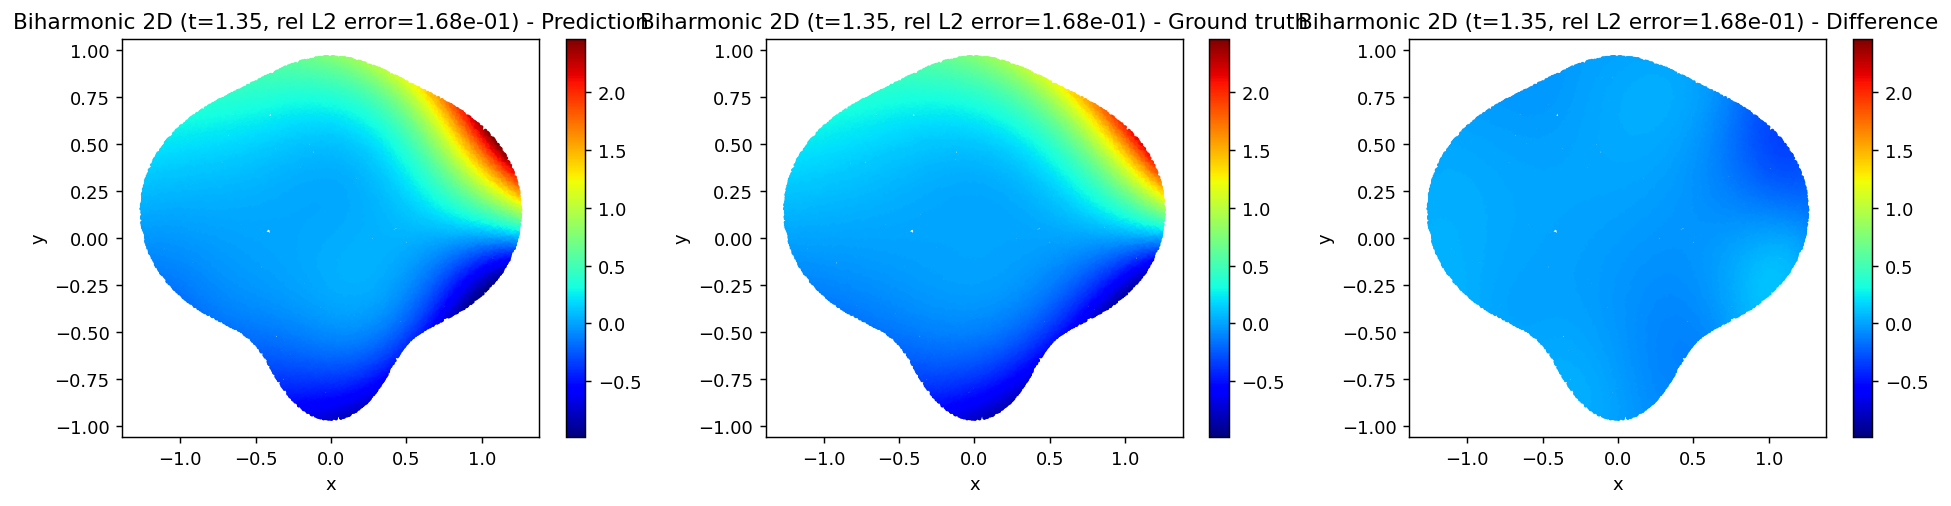

In [36]:
xy, u_true, u_pred, err = evaluate_biharmonic_model(biharmonic_model, t_value=1.35)
plot_prediction(xy, u_true, u_pred, title_prefix=f"Biharmonic 2D (t={1.35:.2f}, rel L2 error={err:.2e}) - ")    

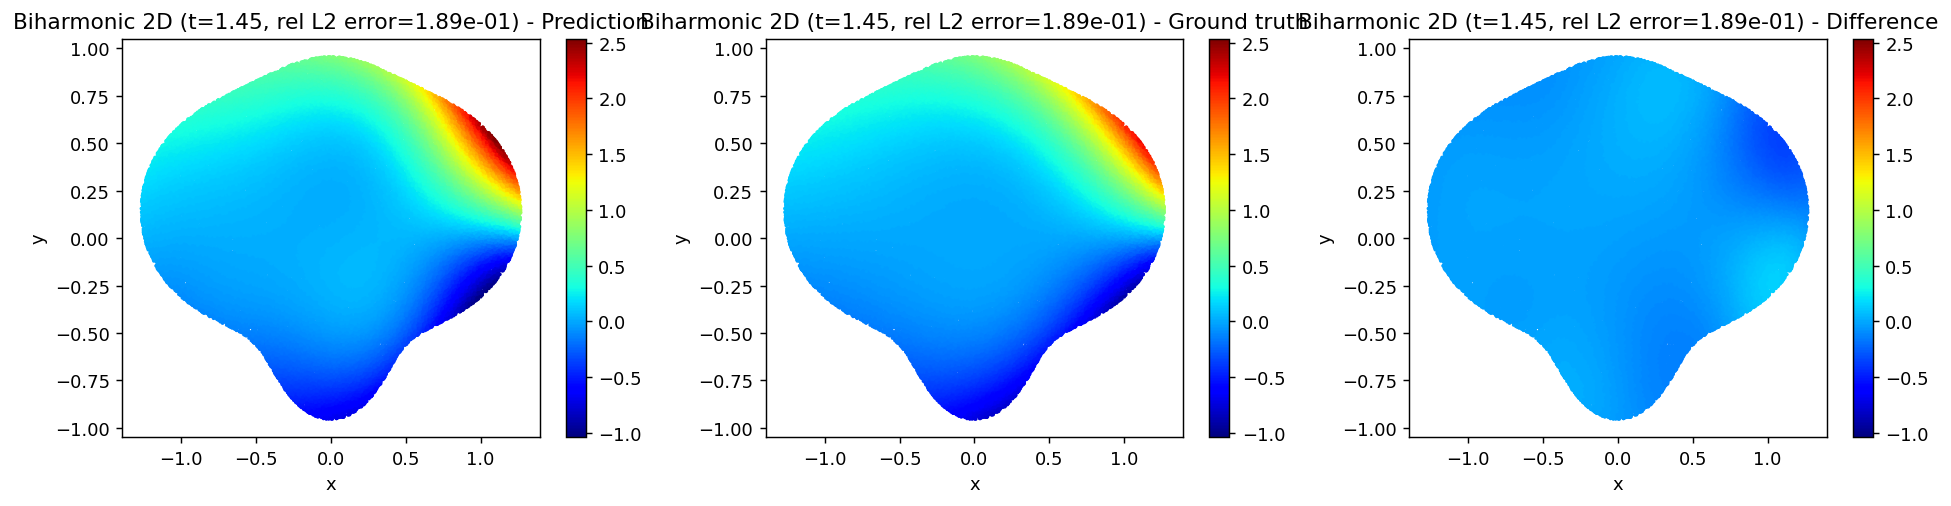

In [37]:
xy, u_true, u_pred, err = evaluate_biharmonic_model(biharmonic_model, t_value=1.45)
plot_prediction(xy, u_true, u_pred, title_prefix=f"Biharmonic 2D (t={1.45:.2f}, rel L2 error={err:.2e}) - ")    

### Nouvelles visualisations

L'article a choisi de visualiser la différence entre prédiction et valeur exacte avec la même échelle que le reste des figures mais nous pouvons prendre une échelle adaptée pour voir la distribution spatiale des erreurs plus précisément.

In [38]:
def plot_prediction_bis(xy, u_true, u_pred, title_prefix=""):
    xy_np = xy.detach().cpu().numpy()
    ut = u_true.detach().cpu().numpy().squeeze()
    up = u_pred.detach().cpu().numpy().squeeze()
    diff = ut - up

    plt.figure()

    sc = plt.scatter(xy_np[:, 0], xy_np[:, 1], c=diff, s=1, cmap="jet")
    plt.title(f"{title_prefix}Difference")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(sc)

    plt.tight_layout()
    plt.show()

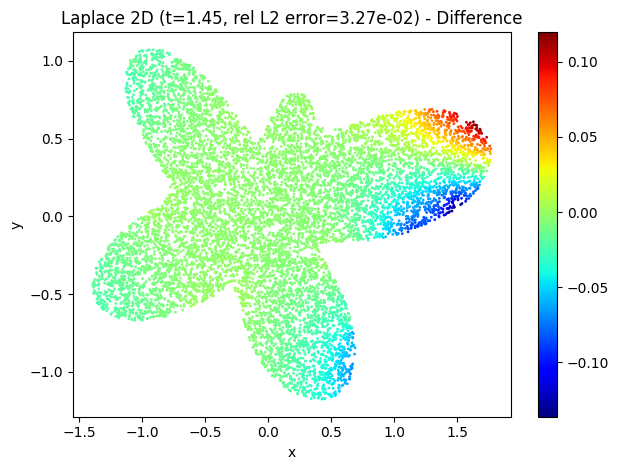

In [39]:
xy, u_true, u_pred, err = evaluate_laplace_model(laplace_model, t_value=1.45, n_eval = 10000)
plot_prediction_bis(xy, u_true, u_pred, title_prefix=f"Laplace 2D (t={1.45:.2f}, rel L2 error={err:.2e}) - ")    

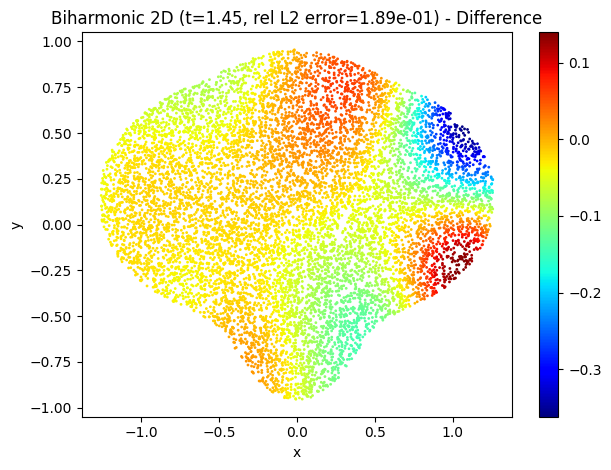

In [40]:
xy, u_true, u_pred, err = evaluate_biharmonic_model(biharmonic_model, t_value=1.45, n_eval = 10000)
plot_prediction_bis(xy, u_true, u_pred, title_prefix=f"Biharmonic 2D (t={1.45:.2f}, rel L2 error={err:.2e}) - ")    